In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Load the dataset
df = pd.read_csv('../final_df.csv')

In [4]:
temp_cols = [
    'NakhonPathom_Meat_Temperature_C', 'PathumThani_Hub_Temperature_C', 
    'Phetchabun_High_Temperature_C', 'Ratchaburi_Veg_Temperature_C'
]

rain_cols = [
    'NakhonPathom_Meat_Rainfall_mm', 'PathumThani_Hub_Rainfall_mm', 
    'Phetchabun_High_Rainfall_mm', 'Ratchaburi_Veg_Rainfall_mm'
]

humid_cols = [
    'NakhonPathom_Meat_Humidity_Percent', 'PathumThani_Hub_Humidity_Percent', 
    'Phetchabun_High_Humidity_Percent', 'Ratchaburi_Veg_Humidity_Percent'
]

soil_cols = [
    'NakhonPathom_Meat_Soil_Moisture', 'PathumThani_Hub_Soil_Moisture', 
    'Phetchabun_High_Soil_Moisture', 'Ratchaburi_Veg_Soil_Moisture'
]

# 2. Create new columns as the "average" across all provinces 
# (axis=1 means row-wise average for each day)
df['Avg_Temperature_C'] = df[temp_cols].mean(axis=1)
df['Avg_Rainfall_mm'] = df[rain_cols].mean(axis=1)
df['Avg_Humidity_Percent'] = df[humid_cols].mean(axis=1)
df['Avg_Soil_Moisture'] = df[soil_cols].mean(axis=1)

# 3. Drop province-level columns to simplify the dataset
all_weather_cols = temp_cols + rain_cols + humid_cols + soil_cols
df = df.drop(columns=all_weather_cols)

In [5]:
df.columns

Index(['Day', 'Month', 'Year', 'DayOfWeek_Num', 'Date_Match', 'Diesel',
       'Price_chicken', 'Price_chili', 'Price_coriander', 'Price_egg',
       'Price_garlic', 'Price_lime', 'Price_onion', 'Price_peanut',
       'Price_pork', 'Price_shallot', 'Price_shrimp', 'Price_spring_onion',
       'Price_tamarind_juice', 'Important_Days', 'Avg_Temperature_C',
       'Avg_Rainfall_mm', 'Avg_Humidity_Percent', 'Avg_Soil_Moisture'],
      dtype='object')

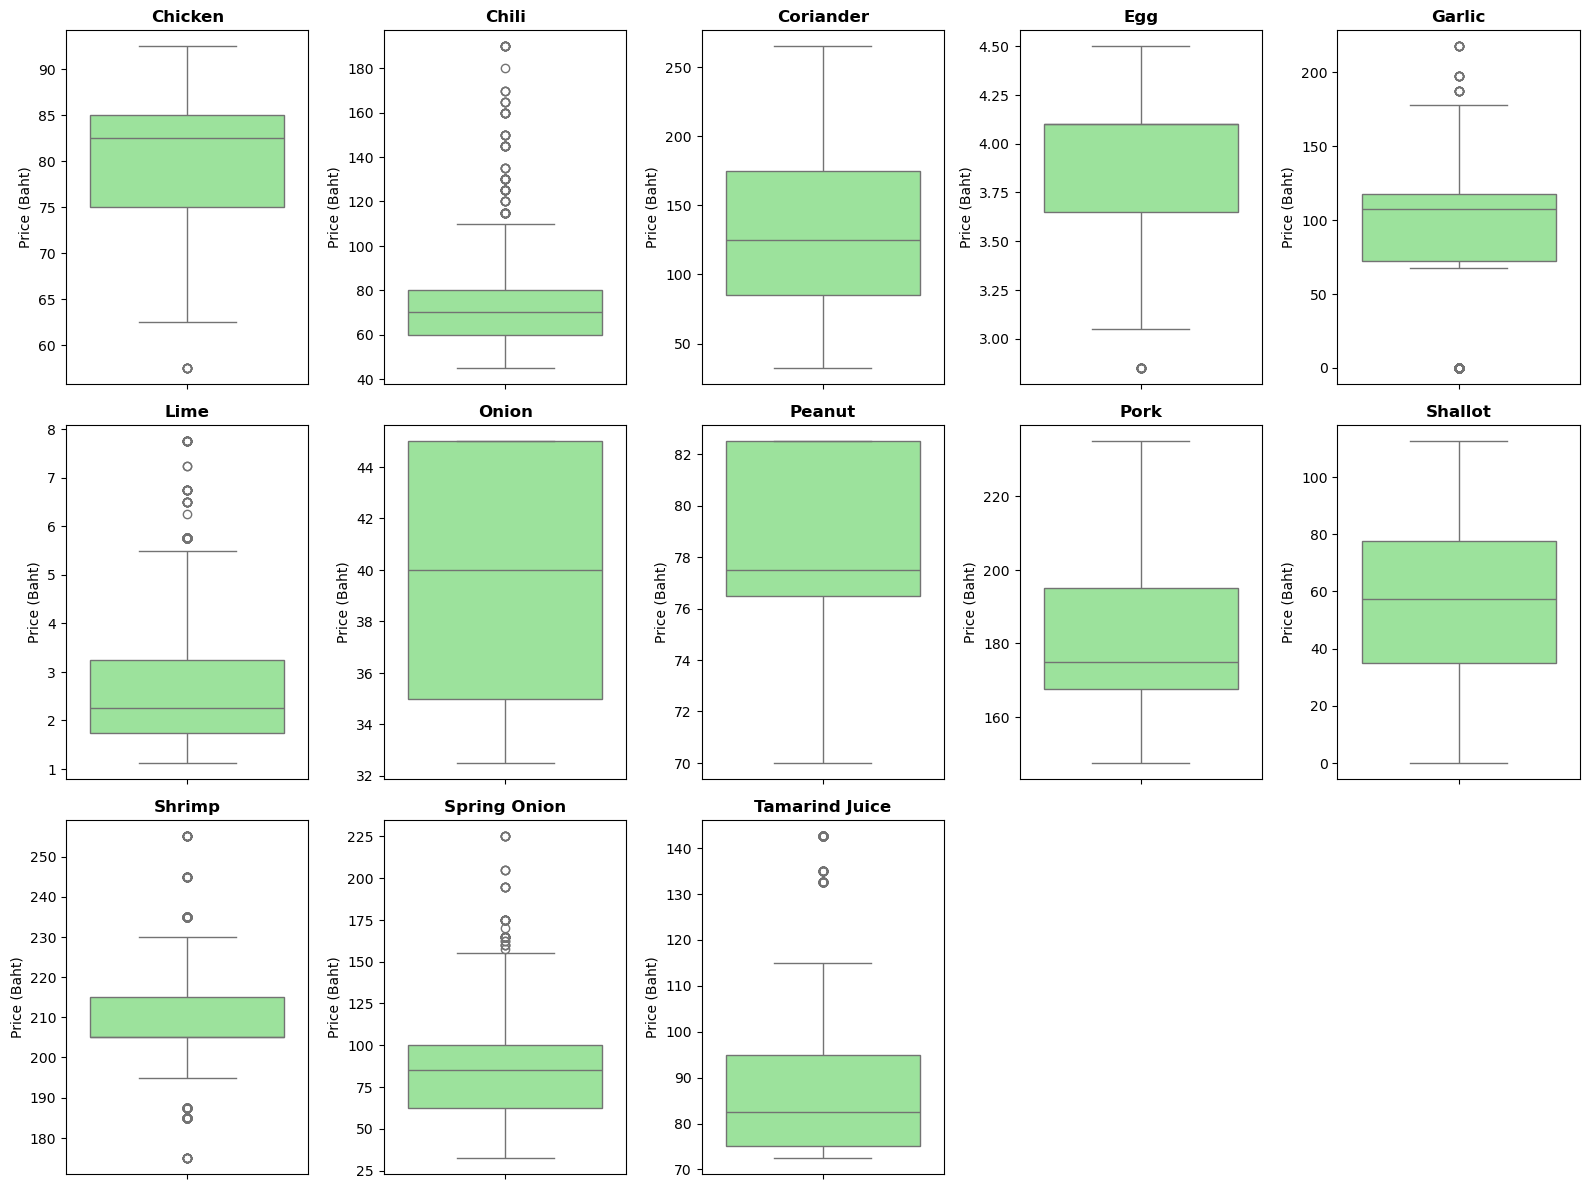

In [6]:
# Select only columns that start with 'Price_'
price_columns = [col for col in df.columns if col.startswith('Price_')]

# 2. Define subplot layout (set 5 plots per row)
num_cols = 5
num_rows = math.ceil(len(price_columns) / num_cols)  # Calculate required number of rows

# 3. Create the main figure and subplots (Axes)
# Adjust figure height based on number of rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easier iteration

# 4. Loop through each ingredient and plot boxplots
for i, col in enumerate(price_columns):
    # Plot boxplot with Y-axis as the price of each ingredient (independent scale)
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    
    # Format subplot title by removing 'Price_' and improving readability
    ingredient_name = col.replace('Price_', '').replace('_', ' ').title()
    axes[i].set_title(ingredient_name, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price (Baht)', fontsize=10)

# 5. Hide unused subplots (if total plots are not divisible by 5)
for j in range(len(price_columns), len(axes)):
    axes[j].set_visible(False)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

Detected 6 features with outliers



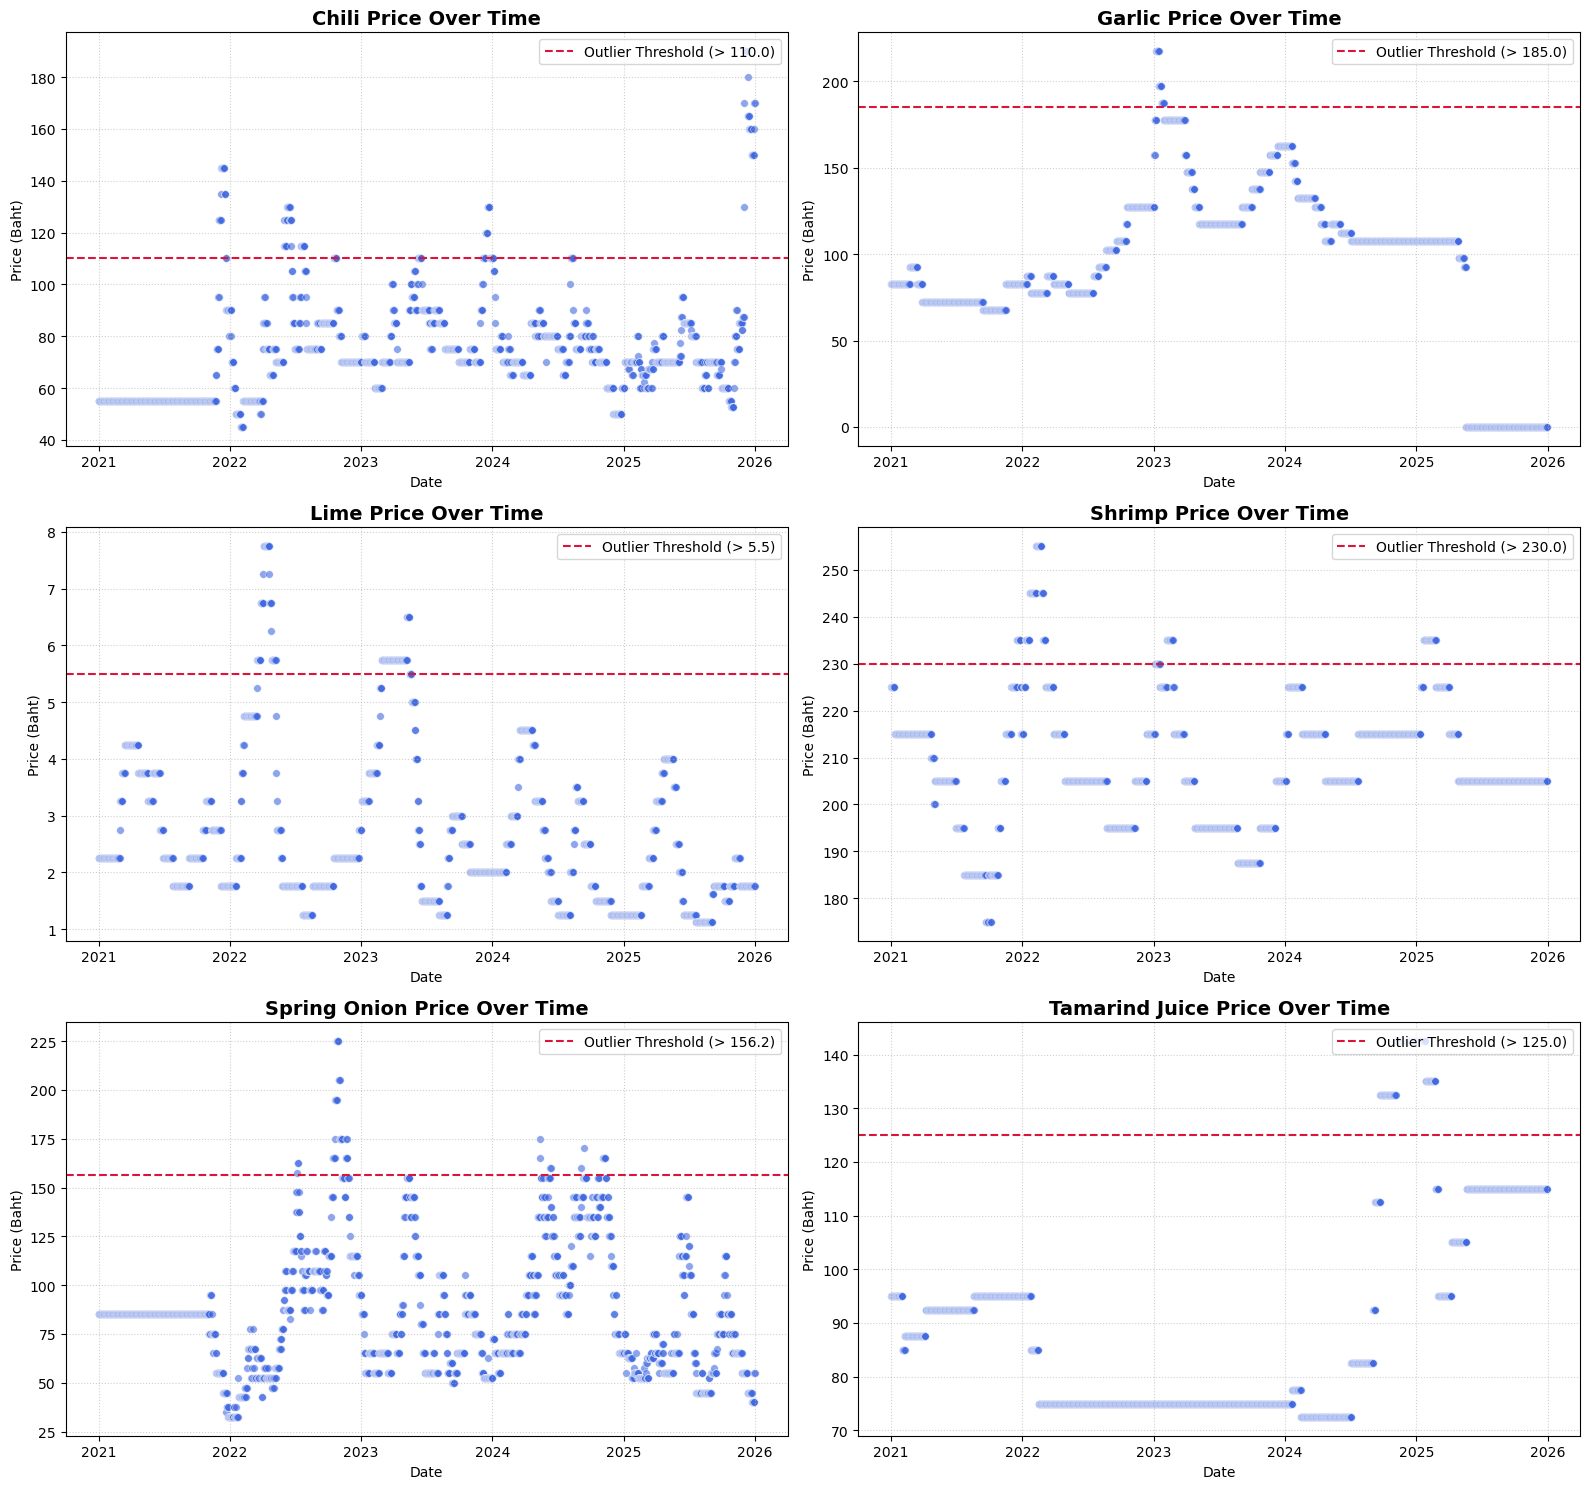

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Load data and process date column
df['Date_Match'] = pd.to_datetime(df['Date_Match'], format="%d/%m/%Y")

# 2. Function to detect columns with outliers (using IQR method)
price_cols = [col for col in df.columns if col.startswith('Price_')]
outlier_features = []

for col in price_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    if (df[col] > upper_bound).any():
        outlier_features.append(col)

print(f"Detected {len(outlier_features)} features with outliers\n")

# 3. Configure subplots (2 plots per row for better readability)
num_cols = 2
num_rows = math.ceil(len(outlier_features) / num_cols)

# Increase height (5 * num_rows) to provide enough space
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 5 * num_rows))
axes = axes.flatten()

# 4. Loop through each feature and plot scatter plots
for i, col in enumerate(outlier_features):
    # Plot scatter points
    sns.scatterplot(data=df, x='Date_Match', y=col, ax=axes[i], alpha=0.6, s=30, color='royalblue')
    
    # Recalculate upper bound to draw threshold line
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    upper_bound = Q3 + 1.5 * (Q3 - Q1)
    
    # Draw red dashed line indicating outlier threshold
    axes[i].axhline(y=upper_bound, color='crimson', linestyle='--', label=f'Outlier Threshold (> {upper_bound:.1f})')
    
    # Customize title and axis labels
    ingredient_name = col.replace('Price_', '').replace('_', ' ').title()
    axes[i].set_title(f"{ingredient_name} Price Over Time", fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date', fontsize=10)
    axes[i].set_ylabel('Price (Baht)', fontsize=10)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle=':', alpha=0.6)

# 5. Hide unused subplots (if number of features is odd)
for j in range(len(outlier_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

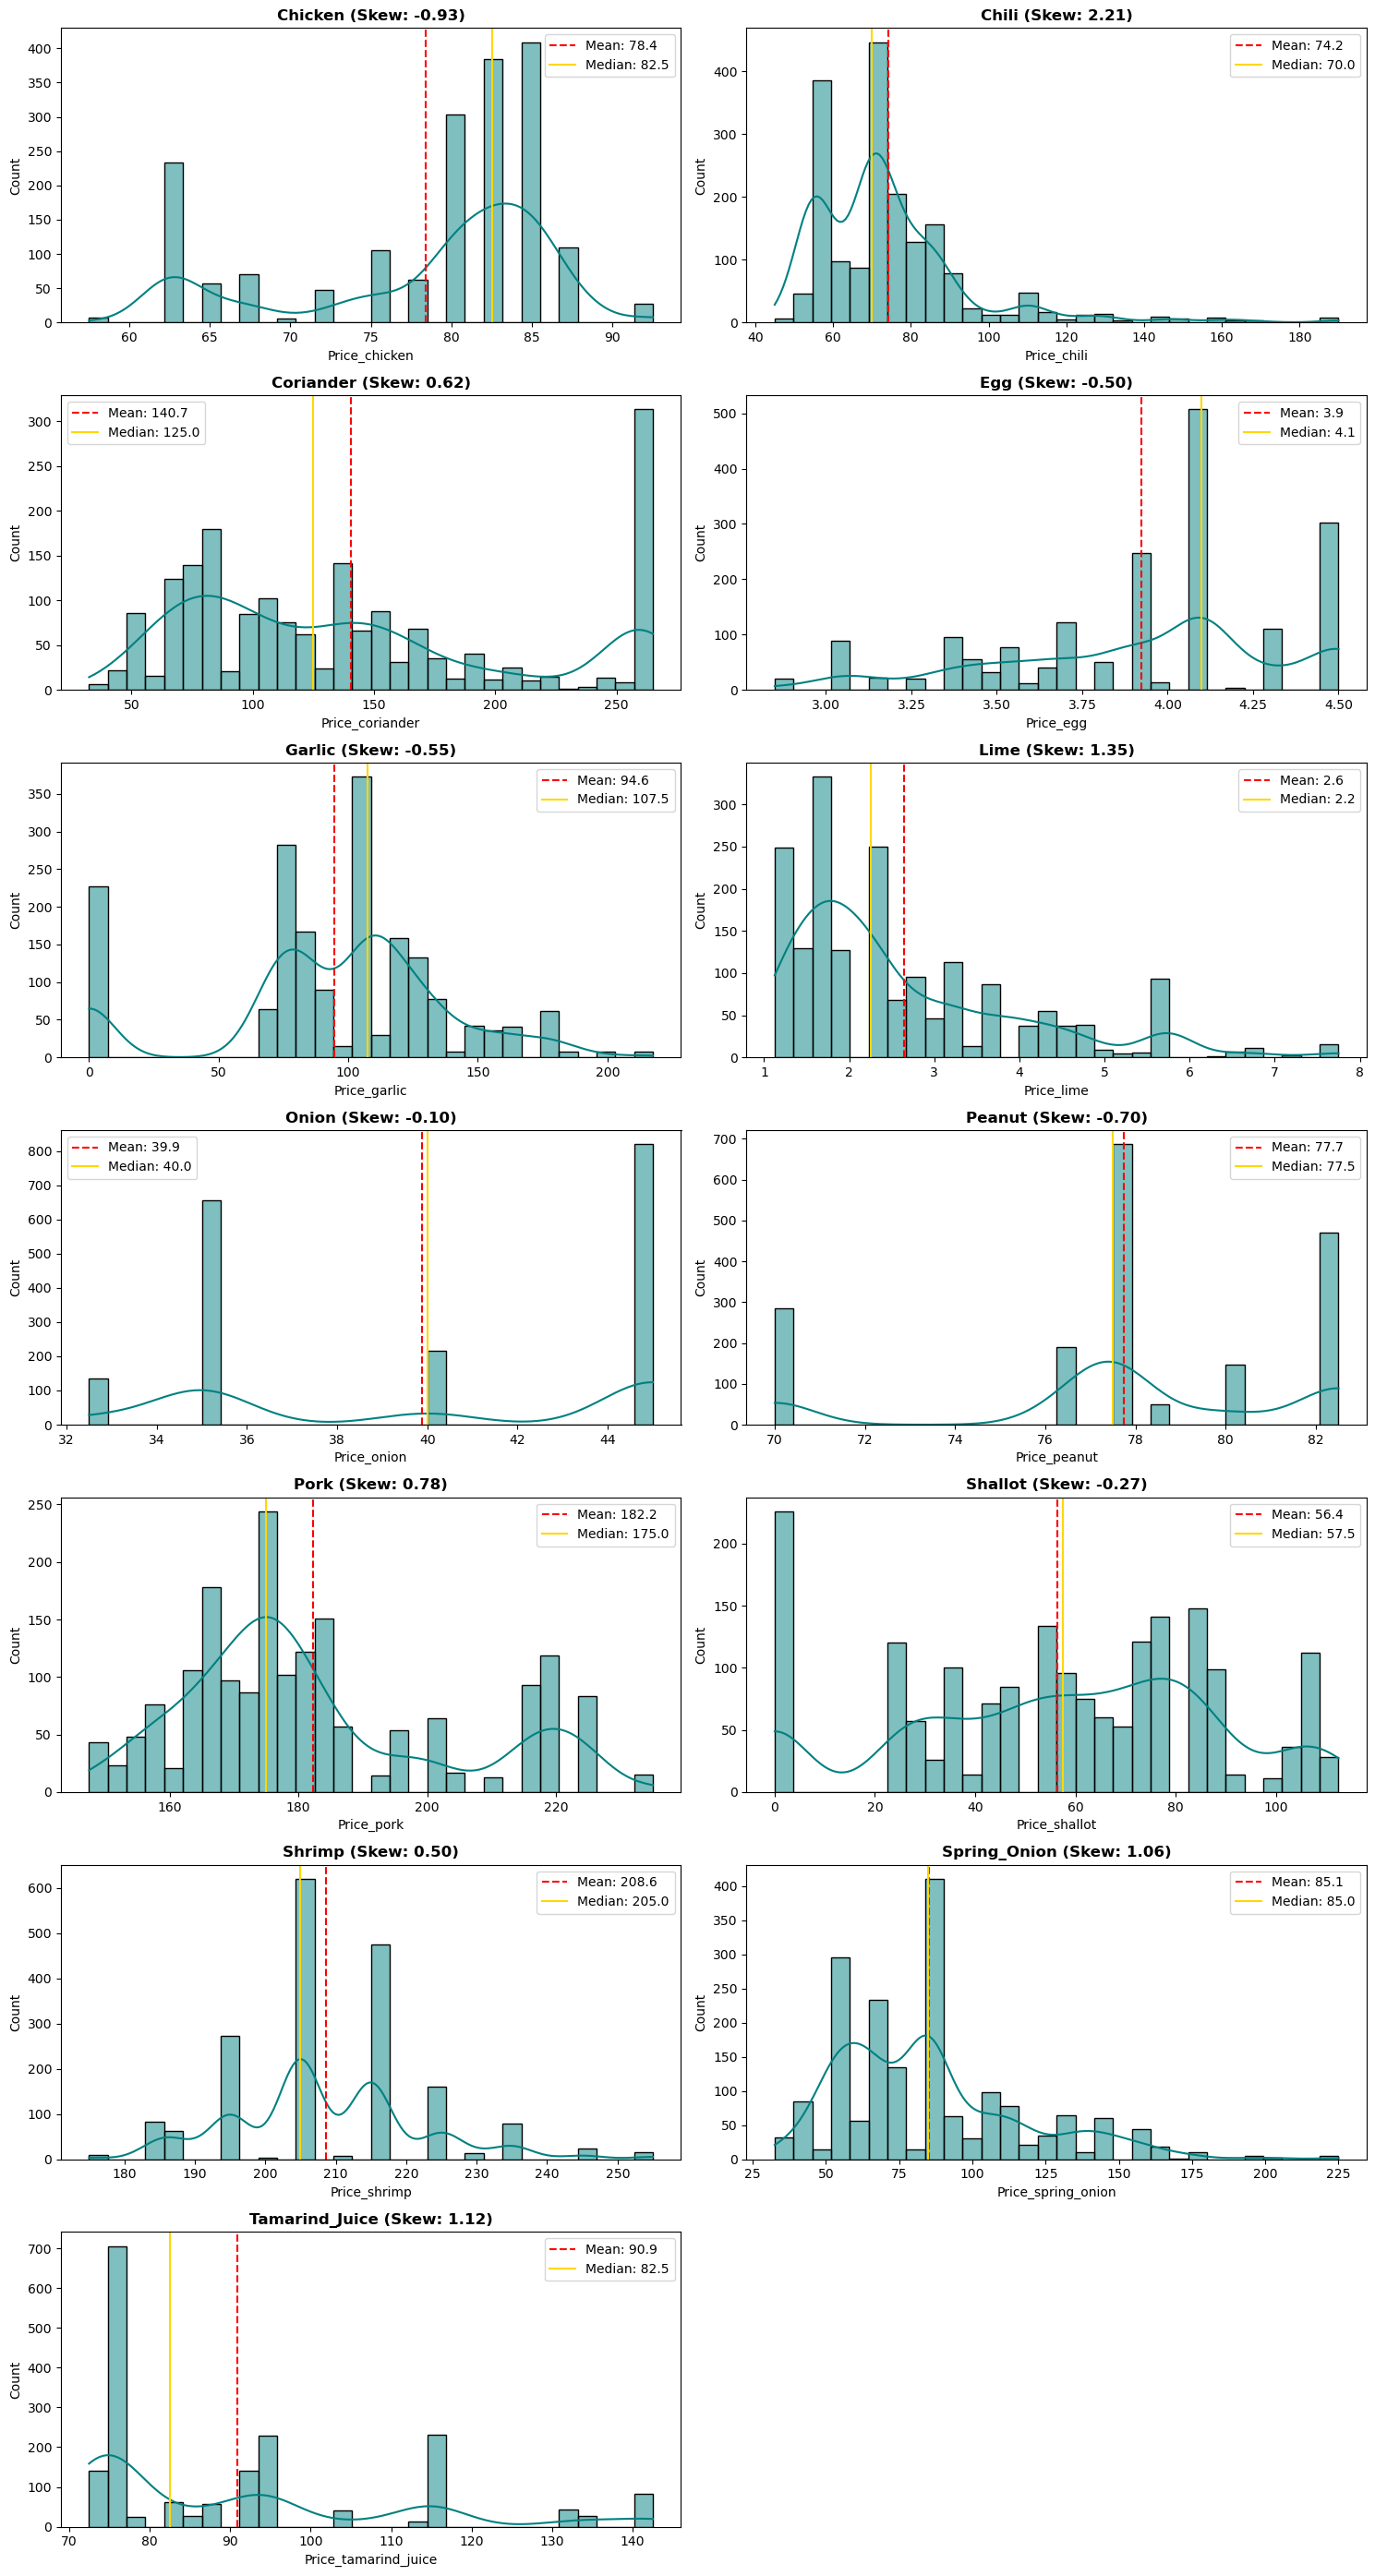

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Load the dataset
price_cols = [col for col in df.columns if col.startswith('Price_')]

# 2. Set the number of rows and columns for the plots
n_cols = 2  # Set 2 plots per row
n_rows = math.ceil(len(price_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))  # Adjust figure size based on number of rows

for i, col in enumerate(price_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot Histogram with KDE (Kernel Density Estimation)
    sns.histplot(df[col].dropna(), kde=True, color='teal', bins=30)
    
    # Calculate Mean and Median
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()
    
    # Draw Mean and Median lines
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    plt.axvline(median_val, color='gold', linestyle='-', label=f'Median: {median_val:.1f}')
    
    # Customize plot
    item_name = col.replace('Price_', '').title()
    plt.title(f'{item_name} (Skew: {skew_val:.2f})', fontweight='bold')
    plt.legend()

plt.tight_layout()
plt.show()

Data preparing

In [10]:
df.columns

Index(['Day', 'Month', 'Year', 'DayOfWeek_Num', 'Date_Match', 'Diesel',
       'Price_chicken', 'Price_chili', 'Price_coriander', 'Price_egg',
       'Price_garlic', 'Price_lime', 'Price_onion', 'Price_peanut',
       'Price_pork', 'Price_shallot', 'Price_shrimp', 'Price_spring_onion',
       'Price_tamarind_juice', 'Important_Days', 'Avg_Temperature_C',
       'Avg_Rainfall_mm', 'Avg_Humidity_Percent', 'Avg_Soil_Moisture'],
      dtype='object')

In [12]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

handling Distribution via Log Transformation

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, RobustScaler
import joblib

def transform_prices(df, columns):
    df_transformed = df.copy()
    
    # Create dictionaries to store scalers and transformers for each column
    scalers_dict = {}
    pt_dict = {}
    
    for col in columns:
        # Create a new transformer and scaler for each column inside the loop
        pt = PowerTransformer(method='yeo-johnson')
        scaler = RobustScaler(quantile_range=(25.0, 75.0))
        
        old_skew = df[col].skew()
        
        # Step 1: Capping
        lower_limit = df_transformed[col].quantile(0.10)  
        upper_limit = df_transformed[col].quantile(0.90)  
        df_transformed[col] = df_transformed[col].clip(lower=lower_limit, upper=upper_limit)
        
        # Step 2: Yeo-Johnson transformation
        df_transformed[col] = pt.fit_transform(df_transformed[[col]].values)
        
        # Step 3: RobustScaler
        df_transformed[col] = scaler.fit_transform(df_transformed[[col]])
        
        # Store fitted scaler and transformer in dictionaries using column name as key
        scalers_dict[col] = scaler
        pt_dict[col] = pt
        
        new_skew = df_transformed[col].skew()
        print(f"{col}: Skew {old_skew:.2f} -> {new_skew:.2f}")
        
    # Return transformed dataframe and dictionaries
    return df_transformed, scalers_dict, pt_dict


df_final, my_scalers, my_pts = transform_prices(train_df, price_cols)

Price_chicken: Skew -0.66 -> -0.43
Price_chili: Skew 1.26 -> 0.01
Price_coriander: Skew 0.47 -> 0.03
Price_egg: Skew -0.38 -> -0.06
Price_garlic: Skew 0.78 -> 0.02
Price_lime: Skew 1.24 -> 0.15
Price_onion: Skew -0.21 -> -0.21
Price_peanut: Skew -0.67 -> -0.19
Price_pork: Skew 0.64 -> 0.21
Price_shallot: Skew 0.14 -> -0.11
Price_shrimp: Skew 0.49 -> -0.04
Price_spring_onion: Skew 0.94 -> 0.03
Price_tamarind_juice: Skew 2.17 -> 0.47


Found 13 columns for plotting


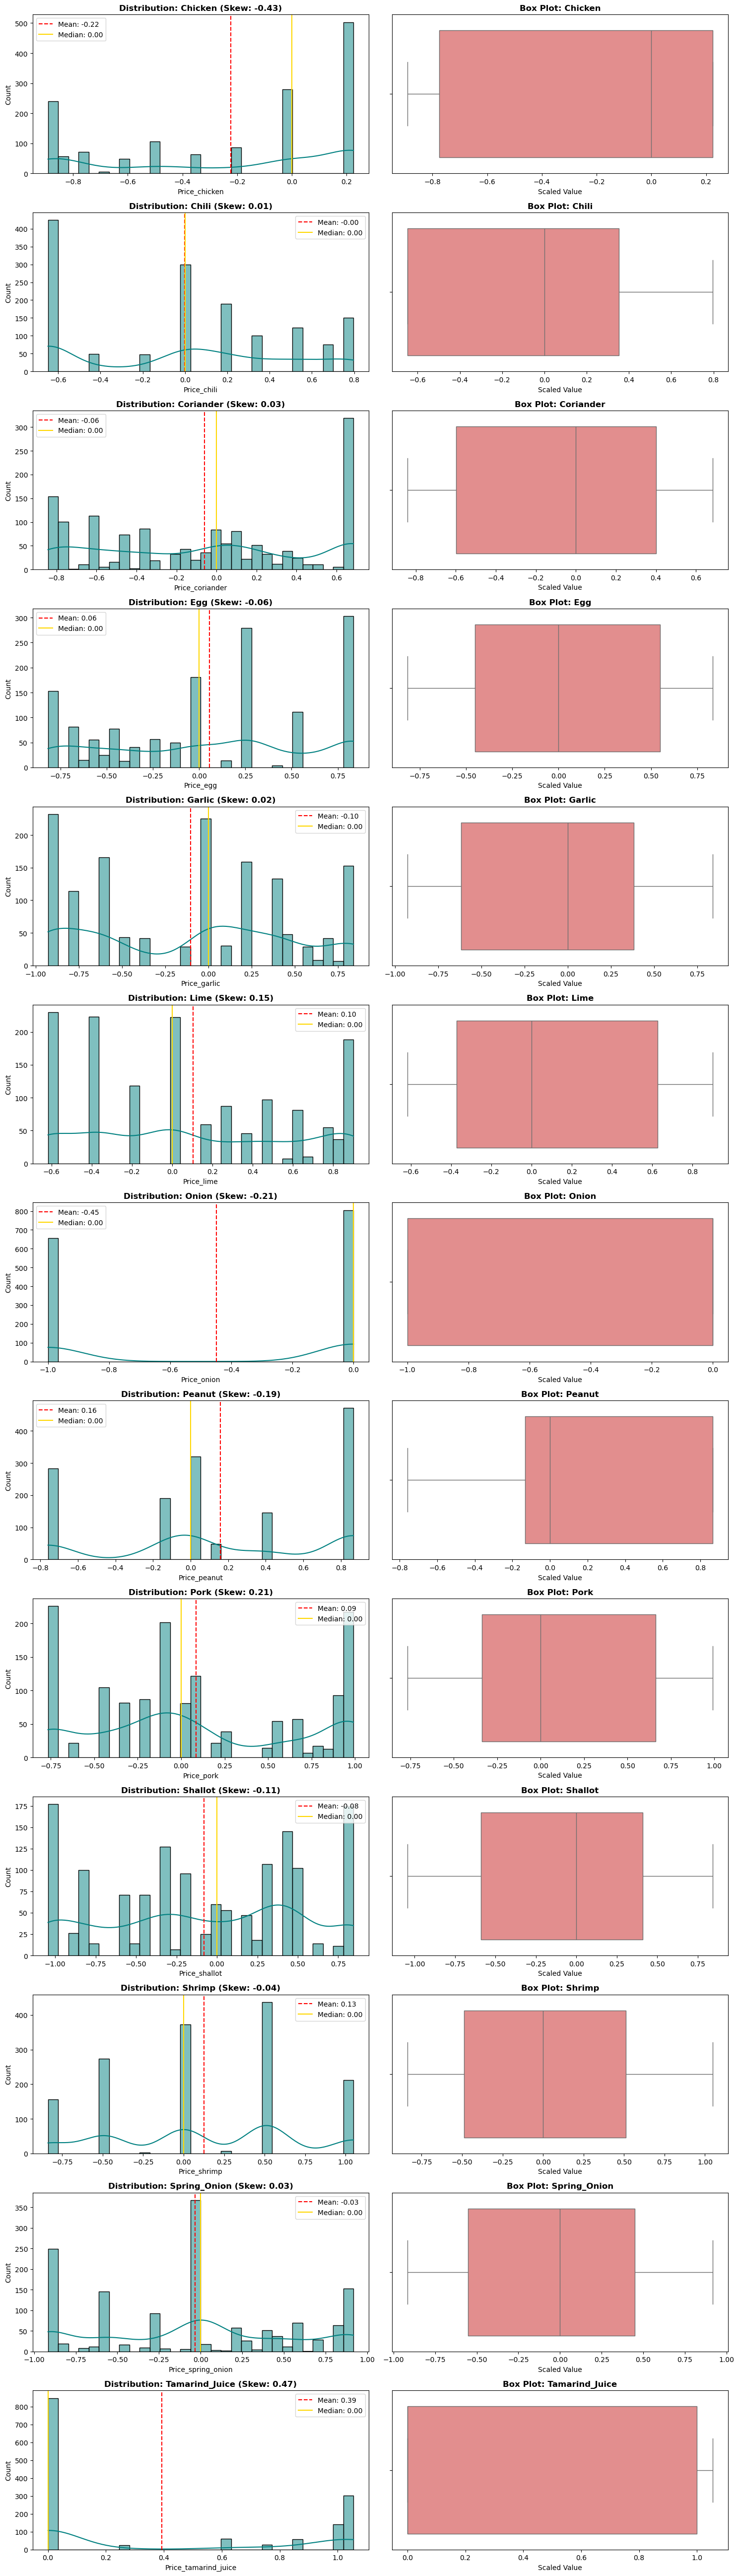

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df_plot = df_final

# 2. Select price-related columns (filter columns starting with 'Price_')
# and exclude '_PercentileClean' or '_Transformed' Zcolumns if they exist
target_cols = [
    col for col in df_plot.columns 
    if col.startswith('Price_') and not col.endswith('_PercentileClean') and not col.endswith('_Transformed')
]

# Verify that columns are found
print(f"Found {len(target_cols)} columns for plotting")

# Set figure size (1 feature = 1 row)
n_features = len(target_cols)
fig, axes = plt.subplots(n_features, 2, figsize=(15, n_features * 4))

# If there is only one column, axes will not be a 2D array → convert to list
if n_features == 1:
    axes = [axes]

for i, col in enumerate(target_cols):
    # ==========================================
    # Left: Distribution Plot
    # ==========================================
    ax_hist = axes[i][0]
    sns.histplot(df_plot[col].dropna(), kde=True, color='teal', bins=30, ax=ax_hist)
    
    # Calculate mean, median, and skewness
    mean_val = df_plot[col].mean()
    median_val = df_plot[col].median()
    skew_val = df_plot[col].skew()
    
    # Draw mean and median lines
    ax_hist.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='gold', linestyle='-', label=f'Median: {median_val:.2f}')
    
    # Customize left plot (remove 'Price_' for cleaner titles)
    item_name = col.replace('Price_', '').title()
    ax_hist.set_title(f'Distribution: {item_name} (Skew: {skew_val:.2f})', fontweight='bold')
    ax_hist.legend()

    # ==========================================
    # Right: Box Plot (check outliers)
    # ==========================================
    ax_box = axes[i][1]
    sns.boxplot(x=df_plot[col].dropna(), color='lightcoral', ax=ax_box)
    
    # Customize right plot
    ax_box.set_title(f'Box Plot: {item_name}', fontweight='bold')
    ax_box.set_xlabel('Scaled Value')

plt.tight_layout()
plt.show()